In [10]:
from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK 02 — LINEAIRE GELEIDINGEN

Selectie: HIWIN PGCW30 / CG30  (smalflens profiel, 30-klasse)

GELEIDING-LASTMODEL  (4-blokken rechthoeksopstelling):

Vier blokken op twee parallelle rails:
Blokken op railpaar A en B, op rail-onderlinge afstand b (railafstand)
Blokken op as-richting afstand a (blokafstand)

Krachtverdeling (superpositie):
F0           = Fz / 4           [gemiddeld per blok, symmetrische last]
δ_rails      = |Mx| / b         [koppel om X → kracht over railafstand b]
δ_blokken    = |My| / a         [koppel om Y → kracht over blokafstand a]
F_blok_max   = F0 + ½δ_rails + ½δ_blokken   [ongunstige hoekblok]
F_blok_min   = F0 − ½δ_rails − ½δ_blokken   [gunstige hoekblok]

Bewijs δ_rails:
       Mx wordt opgenomen door een krachtkoppel ΔF over arm b:
           2ΔF × (b/2) = Mx  →  ΔF = Mx/b
       Elk blok op de zwaar belaste rail draagt ΔF/2 extra:
           bijdrage per blok = ½ × δ_rails  ✓

Horizontale last Fx:
Fx (M1 versnelling) werkt in de railrichting en wordt direct als glijkracht op de blokken overgedragen. Het wordt NIET meegeteld in F_blok_max (dat is de normaalbelasting), maar apart getoetst aan de horizontale capaciteit van het blok (rating load Cx).

Levensduur (HIWIN-methode):
L10 = (C / (fw × P))³ × L_basis    [km]
L_basis = 50 km  (HIWIN-catalogus basiswaarde, ref. HIWIN Ball-Type
Linear Guideway Technical Information, §4.1)
fw      = 1.3    (belastingsfactor, HIWIN §4.3)

Operationele levensduureis:
30 c/h × 8 h/dag × 220 d/jaar × 2 slagen × 2.2 m = 232 km/jaar
Doel: 10 jaar × 232 × factor 2.5 = 5 800 km  (consistent met nb03/04)



In [11]:
# Operationeel profiel (gedeeld met nb03/04)
CYCLI_PER_UUR        = 30
BEDRIJFSUREN_PER_DAG = 8
WERKDAGEN_PER_JAAR   = 220
SLAG_M               = 2.200   # m — M1 werkslag
VEREISTE_JAREN       = 10
FACTOR_LEVENSDUUR    = 2.5     # L10 marge

_km_per_jaar = (CYCLI_PER_UUR * BEDRIJFSUREN_PER_DAG * WERKDAGEN_PER_JAAR
                * 2 * SLAG_M / 1000.0)
_DOEL_KM     = VEREISTE_JAREN * _km_per_jaar * FACTOR_LEVENSDUUR


def veilige_del(a: float, b: float, fallback: float = float("nan")) -> float:
    return fallback if abs(b) < 1e-16 else a / b


def levensduur_geleiding_km(
    C_N: float, fw: float, P_N: float, basis_km: float = 50.0
) -> float:
    """
    HIWIN-levensduurformule voor kogelgeleiding.
    L10 = (C / (fw × P))³ × basis_km

    Parameters
    ----------
    C_N      : dynamische belastingscapaciteit per blok [N]
    fw       : belastingsfactor (schok, dynamica)
    P_N      : equivalente belasting per blok [N]
    basis_km : HIWIN basislevensduur = 50 km (cataloguswaarde)
    """
    if P_N <= 0.0:
        return math.inf
    return (C_N / (fw * P_N)) ** 3 * basis_km


def toon_dataframe(naam: str, df: pd.DataFrame, max_rijen: int = 20) -> None:
    print(f"\n=== {naam.upper()} ===")
    if len(df) > max_rijen:
        print(df.head(max_rijen).to_string(index=False))
        print(f"... ({len(df)} rijen in totaal)")
    else:
        print(df.to_string(index=False))

FALLBACK

In [12]:
try:
    resultaten_interface
except NameError:
    resultaten_interface = {
        "export_voor_volgende_modules": {
            "massa_effectief_op_slede_kg":    120.2,  # Tom v19,
            "massa_te_versnellen_door_m1_kg": 120.2 , # Tom v19,
            "Fx_max_N":  105.30377822832081,
            "Fy_max_N":    0.0,
            "Fz_max_N": 1179.3,  # Tom v19.287580523783,
            "Mx_max_Nm":  17.044384736161795,
            "My_max_Nm": 527.0,  # Tom v19.7836254470391,
            "Mz_max_Nm":   1.3899604176254257,
        },
        "lastgevallen": pd.DataFrame([
            {"lastgeval": "rust_0_graden",    "Fx_N":   0.0,  "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":    0.00, "My_Nm": 494.21, "Mz_Nm":  0.00},
            {"lastgeval": "rust_plus_90",     "Fx_N":   0.0,  "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":  -17.04, "My_Nm": 477.17, "Mz_Nm":  0.00},
            {"lastgeval": "rust_min_90",      "Fx_N":   0.0,  "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":   17.04, "My_Nm": 477.17, "Mz_Nm":  0.00},
            {"lastgeval": "versnellen_0_graden","Fx_N": 105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":   0.00, "My_Nm": 494.78, "Mz_Nm":  0.00},
            {"lastgeval": "versnellen_plus_90","Fx_N":  105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":  -17.04, "My_Nm": 477.74, "Mz_Nm": -1.39},
            {"lastgeval": "versnellen_min_90", "Fx_N":  105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":   17.04, "My_Nm": 477.74, "Mz_Nm":  1.39},
            {"lastgeval": "vertragen_0_graden","Fx_N": -105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":   0.00, "My_Nm": 493.64, "Mz_Nm":  0.00},
            {"lastgeval": "vertragen_plus_90", "Fx_N": -105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":  -17.04, "My_Nm": 476.60, "Mz_Nm":  1.39},
            {"lastgeval": "vertragen_min_90",  "Fx_N": -105.3, "Fy_N": 0.0, "Fz_N": -1291.29, "Fz_abs_N": 1291.29, "Mx_Nm":   17.04, "My_Nm": 476.60, "Mz_Nm": -1.39},
        ]),
    }

CONFIGURATIE

In [13]:
@dataclass(frozen=True)
class ConfiguratieGeleidingen:
    """
    HIWIN PGCW30 / CG30  — cataloguswaarden (HIWIN Linear Guideway catalogue,
    serie PGCW30, normale voorspanning, kwaliteitsklasse C).

    Belastingscapaciteiten:
        C_dyn     : 48 500 N    (dynamisch, vertikaal — 'normal' richting)
        C0        : 71 870 N    (statisch)
        Cx_rated  :  8 500 N    (horizontaal, rijrichting — voor Fx-check)
        Mx/My/Mz  : moment-capaciteiten [Nm]

    Benuttingslimieten:
        statisch  ≤ 0.20  (conservatief; HIWIN adviseert < 0.33)
        dynamisch ≤ 0.10  (extra conservatief vanwege verwachte vibratielast;
                           HIWIN adviseert < 0.33 voor levensduurberekening)
        Toelichting: de lage dynamische limiet is bewust gekozen als marge
        op trillingen en schokken in het M2-systeem. Als de versnellingen
        definitief zijn vastgesteld, kan deze waarde worden herzien.
        moment    ≤ 0.50  (HIWIN adviseert ≤ 0.50 voor gecombineerde last)
    """
    naam_geleiding: str = "HIWIN PGCW30 / CG30"

    # Cataloguswaarden
    C_dynamisch_geleiding_N:    float = 48_500.0
    C0_geleiding_N:             float = 71_870.0
    Cx_horizontaal_geleiding_N: float =  8_500.0   # horizontale capaciteit (Fx-richting)
    Mx_toelaatbaar_geleiding_Nm: float = 792.0
    My_toelaatbaar_geleiding_Nm: float = 583.0
    Mz_toelaatbaar_geleiding_Nm: float = 583.0

    # Stijfheid in Z (belast richting)
    stijfheid_blok_z_N_m:       float = 5.5e8     # N/m — HIWIN technische data

    # Levensduur
    basislevensduur_geleiding_km: float = 50.0     # HIWIN catalogus basiswaarde
    doel_levensduur_geleiding_km: float = _DOEL_KM # afgeleid uit operationeel profiel
    factor_fw:                    float = 1.3       # belastingsfactor (HIWIN §4.3)
    minimum_statische_veiligheid: float = 3.0       # s0_min = C0 / P

    # Benuttingslimieten
    limiet_benutting_geleiding_statisch:  float = 0.20
    limiet_benutting_geleiding_dynamisch: float = 0.10   # bewust conservatief, zie docstring
    limiet_benutting_geleiding_moment:    float = 0.50
    limiet_benutting_geleiding_horizontaal: float = 0.50 # Fx / Cx

    # Scan-instellingen
    optimaliseer_geometrie:     bool  = True
    railafstand_min_m:          float = 0.10
    railafstand_max_m:          float = 0.22
    blokafstand_min_m:          float = 0.12
    blokafstand_max_m:          float = 0.35
    aantal_stappen_railafstand: int   = 61
    aantal_stappen_blokafstand: int   = 81

KRACHTVERDELING PER BLOK

In [14]:
def verdeel_last_over_blokken(
    Fz_abs_N:     float,
    Mx_Nm:        float,
    My_Nm:        float,
    railafstand_m: float,
    blokafstand_m: float,
) -> Dict[str, float]:
    """
    Krachtverdeling over 4 blokken in een 2×2-rechthoeksopstelling.
    Zie module-docstring voor afleiding.
    """
    if railafstand_m <= 0.0 or blokafstand_m <= 0.0:
        nan = float("nan")
        return {"F0_N": nan, "delta_rails_N": nan, "delta_blokken_N": nan,
                "F_blok_max_N": nan, "F_blok_min_N": nan, "uplift": True}

    F0           = Fz_abs_N / 4.0
    delta_rails  = abs(Mx_Nm) / railafstand_m
    delta_blokken = abs(My_Nm) / blokafstand_m
    F_max = F0 + 0.5 * delta_rails + 0.5 * delta_blokken
    F_min = F0 - 0.5 * delta_rails - 0.5 * delta_blokken

    return {
        "F0_N":           F0,
        "delta_rails_N":  delta_rails,
        "delta_blokken_N": delta_blokken,
        "F_blok_max_N":   F_max,
        "F_blok_min_N":   F_min,
        "uplift":         bool(F_min < 0.0),
    }


def tabel_lastverdeling(
    lastgevallen: pd.DataFrame,
    railafstand_m: float,
    blokafstand_m: float,
) -> pd.DataFrame:
    rijen = []
    for _, rij in lastgevallen.iterrows():
        v = verdeel_last_over_blokken(
            float(rij["Fz_abs_N"]), float(rij["Mx_Nm"]),
            float(rij["My_Nm"]), railafstand_m, blokafstand_m)
        rijen.append({**rij.to_dict(), **v})
    return pd.DataFrame(rijen)


def bepaal_ongunstigste_geleidingslasten(
    lastverdeling: pd.DataFrame,
) -> Dict[str, float]:
    idx_F  = lastverdeling["F_blok_max_N"].idxmax()
    idx_Mx = lastverdeling["Mx_Nm"].abs().idxmax()
    idx_My = lastverdeling["My_Nm"].abs().idxmax()
    idx_Mz = lastverdeling["Mz_Nm"].abs().idxmax()
    idx_Fx = lastverdeling["Fx_N"].abs().idxmax()

    return {
        "lastgeval_F_blok":          str(lastverdeling.loc[idx_F,  "lastgeval"]),
        "F_blok_max_N":              float(lastverdeling.loc[idx_F,  "F_blok_max_N"]),
        "F_blok_min_N":              float(lastverdeling.loc[idx_F,  "F_blok_min_N"]),
        "uplift_ergens":             bool(lastverdeling["uplift"].any()),
        "aantal_uplift_lastgevallen": int(lastverdeling["uplift"].sum()),
        "lastgeval_Mx":              str(lastverdeling.loc[idx_Mx, "lastgeval"]),
        "Mx_max_Nm":                 float(abs(lastverdeling.loc[idx_Mx, "Mx_Nm"])),
        "lastgeval_My":              str(lastverdeling.loc[idx_My, "lastgeval"]),
        "My_max_Nm":                 float(abs(lastverdeling.loc[idx_My, "My_Nm"])),
        "lastgeval_Mz":              str(lastverdeling.loc[idx_Mz, "lastgeval"]),
        "Mz_max_Nm":                 float(abs(lastverdeling.loc[idx_Mz, "Mz_Nm"])),
        # Horizontale kracht (rijrichting, voor Cx-check)
        "lastgeval_Fx":              str(lastverdeling.loc[idx_Fx, "lastgeval"]),
        "Fx_max_N":                  float(abs(lastverdeling.loc[idx_Fx, "Fx_N"])),
    }

DIMENSIONERING

In [15]:
def dimensioneer_geleidingen(
    cfg: ConfiguratieGeleidingen,
    samenvatting: Dict[str, float],
) -> Dict[str, float]:
    """Minimum vereiste capaciteiten voor de geselecteerde geleiding."""
    P_eq = samenvatting["F_blok_max_N"]
    C_dyn_vereist = P_eq * cfg.factor_fw * (
        cfg.doel_levensduur_geleiding_km / cfg.basislevensduur_geleiding_km
    ) ** (1.0 / 3.0)
    C0_vereist = cfg.minimum_statische_veiligheid * P_eq
    return {
        "P_eq_blok_N":      P_eq,
        "C_dyn_vereist_N":  C_dyn_vereist,
        "C0_vereist_N":     C0_vereist,
        "Mx_vereist_Nm":    samenvatting["Mx_max_Nm"] / cfg.limiet_benutting_geleiding_moment,
        "My_vereist_Nm":    samenvatting["My_max_Nm"] / cfg.limiet_benutting_geleiding_moment,
        "Mz_vereist_Nm":    samenvatting["Mz_max_Nm"] / cfg.limiet_benutting_geleiding_moment,
        "Cx_vereist_N":     samenvatting["Fx_max_N"]  / cfg.limiet_benutting_geleiding_horizontaal,
    }

VERIFICATIE

In [16]:
def verifieer_geleidingen(
    cfg:             ConfiguratieGeleidingen,
    samenvatting:    Dict[str, float],
    railafstand_m:   float,
) -> Dict[str, float]:
    """Berekent benuttingen en afgeleid gedrag."""
    P_eq = samenvatting["F_blok_max_N"]

    # Rolstijfheid: doorbuiging zijkant onder Mx
    delta_rol_m  = veilige_del(
        0.5 * samenvatting["Mx_max_Nm"] / railafstand_m,
        cfg.stijfheid_blok_z_N_m, 0.0)
    theta_rol_rad = veilige_del(delta_rol_m, 0.5 * railafstand_m, 0.0)

    lev_km = levensduur_geleiding_km(
        cfg.C_dynamisch_geleiding_N, cfg.factor_fw, P_eq,
        cfg.basislevensduur_geleiding_km)

    return {
        "naam_geleiding":             cfg.naam_geleiding,
        "benutting_statisch":         veilige_del(P_eq, cfg.C0_geleiding_N),
        "benutting_dynamisch":        veilige_del(P_eq, cfg.C_dynamisch_geleiding_N),
        "benutting_Mx":               veilige_del(samenvatting["Mx_max_Nm"],
                                                   cfg.Mx_toelaatbaar_geleiding_Nm),
        "benutting_My":               veilige_del(samenvatting["My_max_Nm"],
                                                   cfg.My_toelaatbaar_geleiding_Nm),
        "benutting_Mz":               veilige_del(samenvatting["Mz_max_Nm"],
                                                   cfg.Mz_toelaatbaar_geleiding_Nm),
        "benutting_horizontaal_Fx":   veilige_del(samenvatting["Fx_max_N"],
                                                   cfg.Cx_horizontaal_geleiding_N),
        "levensduur_km":              lev_km,
        "marge_levensduur":           veilige_del(lev_km, cfg.doel_levensduur_geleiding_km),
        "zakking_zijde_mm":           1000.0 * delta_rol_m,
        "rolhoek_graden":             theta_rol_rad * 180.0 / math.pi,
        "uplift_ergens":              bool(samenvatting["uplift_ergens"]),
        "aantal_uplift_lastgevallen": int(samenvatting["aantal_uplift_lastgevallen"]),
    }


def maak_pass_fail_geleidingen(
    cfg: ConfiguratieGeleidingen,
    controle: Dict[str, float],
) -> pd.DataFrame:
    doel = cfg.doel_levensduur_geleiding_km
    return pd.DataFrame([
        {"controle": "geen uplift in alle lastgevallen",
         "waarde": controle["aantal_uplift_lastgevallen"], "grens": 0,
         "vergelijking": "==", "eenheid": "-",
         "geslaagd": bool(controle["aantal_uplift_lastgevallen"] == 0)},
        {"controle": "benutting statisch ≤ limiet",
         "waarde": controle["benutting_statisch"],
         "grens": cfg.limiet_benutting_geleiding_statisch,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_statisch"] <= cfg.limiet_benutting_geleiding_statisch)},
        {"controle": "benutting dynamisch ≤ limiet",
         "waarde": controle["benutting_dynamisch"],
         "grens": cfg.limiet_benutting_geleiding_dynamisch,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_dynamisch"] <= cfg.limiet_benutting_geleiding_dynamisch)},
        {"controle": "benutting Mx ≤ limiet",
         "waarde": controle["benutting_Mx"],
         "grens": cfg.limiet_benutting_geleiding_moment,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_Mx"] <= cfg.limiet_benutting_geleiding_moment)},
        {"controle": "benutting My ≤ limiet",
         "waarde": controle["benutting_My"],
         "grens": cfg.limiet_benutting_geleiding_moment,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_My"] <= cfg.limiet_benutting_geleiding_moment)},
        {"controle": "benutting Mz ≤ limiet",
         "waarde": controle["benutting_Mz"],
         "grens": cfg.limiet_benutting_geleiding_moment,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_Mz"] <= cfg.limiet_benutting_geleiding_moment)},
        {"controle": "benutting horizontaal Fx ≤ limiet",
         "waarde": controle["benutting_horizontaal_Fx"],
         "grens": cfg.limiet_benutting_geleiding_horizontaal,
         "vergelijking": "≤", "eenheid": "-",
         "geslaagd": bool(controle["benutting_horizontaal_Fx"]
                          <= cfg.limiet_benutting_geleiding_horizontaal)},
        {"controle": "levensduur ≥ doel",
         "waarde": controle["levensduur_km"], "grens": doel,
         "vergelijking": "≥", "eenheid": "km",
         "geslaagd": bool(controle["levensduur_km"] >= doel)},
    ])

GEOMETRIE-OPTIMALISATIE

In [17]:
def optimaliseer_rail_en_blokafstand(
    lastgevallen: pd.DataFrame,
    cfg:          ConfiguratieGeleidingen,
) -> Tuple[Dict[str, float], pd.DataFrame]:
    """
    2D parameterscan over (railafstand, blokafstand).
    Doelfunctie: minimaliseer F_blok_max, met harde penalty bij uplift.
    Niet-Pareto: grotere geometrie (hogere massa) is impliciet acceptabel
    zolang de blokbelasting daalt.
    """
    b_vals = np.linspace(cfg.railafstand_min_m, cfg.railafstand_max_m,
                         cfg.aantal_stappen_railafstand)
    a_vals = np.linspace(cfg.blokafstand_min_m, cfg.blokafstand_max_m,
                         cfg.aantal_stappen_blokafstand)
    rijen = []
    for b in b_vals:
        for a in a_vals:
            tab    = tabel_lastverdeling(lastgevallen, b, a)
            Fmax   = float(tab["F_blok_max_N"].max())
            Fmin   = float(tab["F_blok_min_N"].min())
            uplift = bool(tab["uplift"].any())
            rijen.append({
                "railafstand_m": b, "blokafstand_m": a,
                "railafstand_mm": 1000*b, "blokafstand_mm": 1000*a,
                "F_blok_max_N": Fmax, "F_blok_min_N": Fmin,
                "uplift": uplift,
                "doelfunctie": Fmax + (1e9 if uplift else 0.0),
            })
    scan = (pd.DataFrame(rijen)
            .sort_values(["uplift", "F_blok_max_N", "railafstand_m", "blokafstand_m"],
                         ascending=[True, True, True, True])
            .reset_index(drop=True))
    beste = scan.iloc[0].to_dict()
    return ({
        "railafstand_m": float(beste["railafstand_m"]),
        "blokafstand_m": float(beste["blokafstand_m"]),
        "F_blok_max_N":  float(beste["F_blok_max_N"]),
        "F_blok_min_N":  float(beste["F_blok_min_N"]),
        "uplift":        bool(beste["uplift"]),
    }, scan)


def maak_overzicht_geleidingen(
    railafstand_m:   float,
    blokafstand_m:   float,
    samenvatting:    Dict[str, float],
    controle:        Dict[str, float],
) -> pd.DataFrame:
    return pd.DataFrame([
        ["railafstand gekozen",         1000*railafstand_m,                     "mm"],
        ["blokafstand gekozen",         1000*blokafstand_m,                     "mm"],
        ["maatgevend lastgeval",        samenvatting["lastgeval_F_blok"],         "-"],
        ["F_blok_max (normaal)",        samenvatting["F_blok_max_N"],             "N"],
        ["F_blok_min (normaal)",        samenvatting["F_blok_min_N"],             "N"],
        ["Fx_max (horizontaal)",        samenvatting["Fx_max_N"],                 "N"],
        ["uplift ergens",               samenvatting["uplift_ergens"],             "-"],
        ["max |Mx|",                    samenvatting["Mx_max_Nm"],               "Nm"],
        ["max |My|",                    samenvatting["My_max_Nm"],               "Nm"],
        ["max |Mz|",                    samenvatting["Mz_max_Nm"],               "Nm"],
        ["levensduur",                  controle["levensduur_km"],               "km"],
        ["marge levensduur (L10/doel)", controle["marge_levensduur"],             "-"],
        ["benutting statisch",          controle["benutting_statisch"],            "-"],
        ["benutting dynamisch",         controle["benutting_dynamisch"],           "-"],
        ["benutting horizontaal Fx",    controle["benutting_horizontaal_Fx"],      "-"],
        ["benutting Mx",                controle["benutting_Mx"],                  "-"],
        ["benutting My",                controle["benutting_My"],                  "-"],
        ["benutting Mz",                controle["benutting_Mz"],                  "-"],
        ["zakking zijde",               controle["zakking_zijde_mm"],            "mm"],
        ["rolhoek",                     controle["rolhoek_graden"],             "deg"],
    ], columns=["grootheid", "waarde", "eenheid"])

VISUALISATIE

In [18]:
def plot_scan_geleidingen(
    scan_geometrie: pd.DataFrame,
    beste_geometrie: Dict[str, float],
) -> None:
    """
    2-panel figuur:
      Links : Contour-heatmap F_blok_max over scan-ruimte
      Rechts: Benutting-overzicht van de geselecteerde geleiding
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel 1 — scan contour
    pivot = scan_geometrie.pivot_table(
        index="blokafstand_mm", columns="railafstand_mm", values="F_blok_max_N")
    img = axes[0].contourf(
        pivot.columns.values, pivot.index.values, pivot.values,
        levels=20, cmap="RdYlGn_r")
    plt.colorbar(img, ax=axes[0], label="F_blok_max [N]")
    axes[0].scatter(
        1000*beste_geometrie["railafstand_m"],
        1000*beste_geometrie["blokafstand_m"],
        s=200, color="white", marker="*", zorder=5, label="optimum")
    axes[0].set_xlabel("Railafstand [mm]"); axes[0].set_ylabel("Blokafstand [mm]")
    axes[0].set_title("Scan F_blok_max: rail- vs. blokafstand")
    axes[0].legend(fontsize=9)

    # Panel 2 — benutting bar chart
    ben_labels = ["statisch", "dynamisch", "Mx", "My", "Mz", "Fx (hor.)"]
    ben_vals   = [
        controle_geleiding["benutting_statisch"],
        controle_geleiding["benutting_dynamisch"],
        controle_geleiding["benutting_Mx"],
        controle_geleiding["benutting_My"],
        controle_geleiding["benutting_Mz"],
        controle_geleiding["benutting_horizontaal_Fx"],
    ]
    limieten = [
        cfg.limiet_benutting_geleiding_statisch,
        cfg.limiet_benutting_geleiding_dynamisch,
        cfg.limiet_benutting_geleiding_moment,
        cfg.limiet_benutting_geleiding_moment,
        cfg.limiet_benutting_geleiding_moment,
        cfg.limiet_benutting_geleiding_horizontaal,
    ]
    x = np.arange(len(ben_labels))
    colors = ["#2ca02c" if v <= l else "#d62728"
              for v, l in zip(ben_vals, limieten)]
    axes[1].bar(x, ben_vals, color=colors, alpha=0.85)
    for i, (v, l) in enumerate(zip(ben_vals, limieten)):
        axes[1].plot([i - 0.4, i + 0.4], [l, l], "k--", lw=1.5)
    axes[1].set_xticks(x); axes[1].set_xticklabels(ben_labels, fontsize=9)
    axes[1].set_ylabel("Benutting [-]")
    axes[1].set_title("Benuttingen geselecteerde geleiding\n(stippellijn = limiet)")
    axes[1].set_ylim(0, max(max(ben_vals)*1.25, 1.05))
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

HOOFDBEREKENING

In [19]:
print(f"Operationeel: {_km_per_jaar:.1f} km/jaar  →  "
      f"doel L10 = {_DOEL_KM:.0f} km "
      f"(= {VEREISTE_JAREN} jaar × factor {FACTOR_LEVENSDUUR})")

cfg          = ConfiguratieGeleidingen()
lastgevallen = resultaten_interface["lastgevallen"].copy()

if cfg.optimaliseer_geometrie:
    beste_geometrie, scan_geometrie = optimaliseer_rail_en_blokafstand(
        lastgevallen, cfg)
    railafstand_m = beste_geometrie["railafstand_m"]
    blokafstand_m = beste_geometrie["blokafstand_m"]
else:
    beste_geometrie = {}
    scan_geometrie  = pd.DataFrame()
    railafstand_m   = cfg.railafstand_m
    blokafstand_m   = cfg.blokafstand_m

lastverdeling       = tabel_lastverdeling(lastgevallen, railafstand_m, blokafstand_m)
samenvatting_lasten = bepaal_ongunstigste_geleidingslasten(lastverdeling)
eisen_geleiding     = dimensioneer_geleidingen(cfg, samenvatting_lasten)
controle_geleiding  = verifieer_geleidingen(cfg, samenvatting_lasten, railafstand_m)
pass_fail_geleiding = maak_pass_fail_geleidingen(cfg, controle_geleiding)
overzicht_geleiding = maak_overzicht_geleidingen(
    railafstand_m, blokafstand_m, samenvatting_lasten, controle_geleiding)

Operationeel: 232.3 km/jaar  →  doel L10 = 5808 km (= 10 jaar × factor 2.5)


In [20]:
toon_dataframe("lastverdeling",        lastverdeling)
toon_dataframe("overzicht geleidingen", overzicht_geleiding)
toon_dataframe("pass/fail geleidingen", pass_fail_geleiding)
toon_dataframe("eisen geleiding",       pd.Series(eisen_geleiding).to_frame("waarde"))

print("\n=== BESTE GEOMETRIE ===")
print(pd.Series(beste_geometrie).to_string())
print("\n=== CONTROLE GELEIDING ===")
print(pd.Series(controle_geleiding).to_string())

n_ok = int(pass_fail_geleiding["geslaagd"].sum())
print(f"\n>>> GELEIDINGEN: {n_ok}/{len(pass_fail_geleiding)} checks geslaagd")


=== LASTVERDELING ===
          lastgeval   Fx_N  Fy_N     Fz_N  Fz_abs_N  Mx_Nm  My_Nm  Mz_Nm     F0_N  delta_rails_N  delta_blokken_N  F_blok_max_N  F_blok_min_N  uplift
      rust_0_graden    0.0   0.0 -1291.29   1291.29   0.00 494.21   0.00 322.8225       0.000000      1412.028571   1028.836786   -383.191786    True
       rust_plus_90    0.0   0.0 -1291.29   1291.29 -17.04 477.17   0.00 322.8225      77.454545      1363.342857   1043.221201   -397.576201    True
        rust_min_90    0.0   0.0 -1291.29   1291.29  17.04 477.17   0.00 322.8225      77.454545      1363.342857   1043.221201   -397.576201    True
versnellen_0_graden  105.3   0.0 -1291.29   1291.29   0.00 494.78   0.00 322.8225       0.000000      1413.657143   1029.651071   -384.006071    True
 versnellen_plus_90  105.3   0.0 -1291.29   1291.29 -17.04 477.74  -1.39 322.8225      77.454545      1364.971429   1044.035487   -398.390487    True
  versnellen_min_90  105.3   0.0 -1291.29   1291.29  17.04 477.74   1.39 322.


=== TOP SCAN GEOMETRIE ===
 railafstand_m  blokafstand_m  railafstand_mm  blokafstand_mm  F_blok_max_N  F_blok_min_N  uplift  doelfunctie
         0.220           0.35           220.0           350.0   1044.035487   -398.390487    True 1.000001e+09
         0.218           0.35           218.0           350.0   1044.390783   -398.745783    True 1.000001e+09
         0.216           0.35           216.0           350.0   1044.752659   -399.107659    True 1.000001e+09
         0.214           0.35           214.0           350.0   1045.121298   -399.476298    True 1.000001e+09
         0.212           0.35           212.0           350.0   1045.496894   -399.851894    True 1.000001e+09
         0.210           0.35           210.0           350.0   1045.879643   -400.234643    True 1.000001e+09
         0.208           0.35           208.0           350.0   1046.269753   -400.624753    True 1.000001e+09
         0.206           0.35           206.0           350.0   1046.667438   -401.0

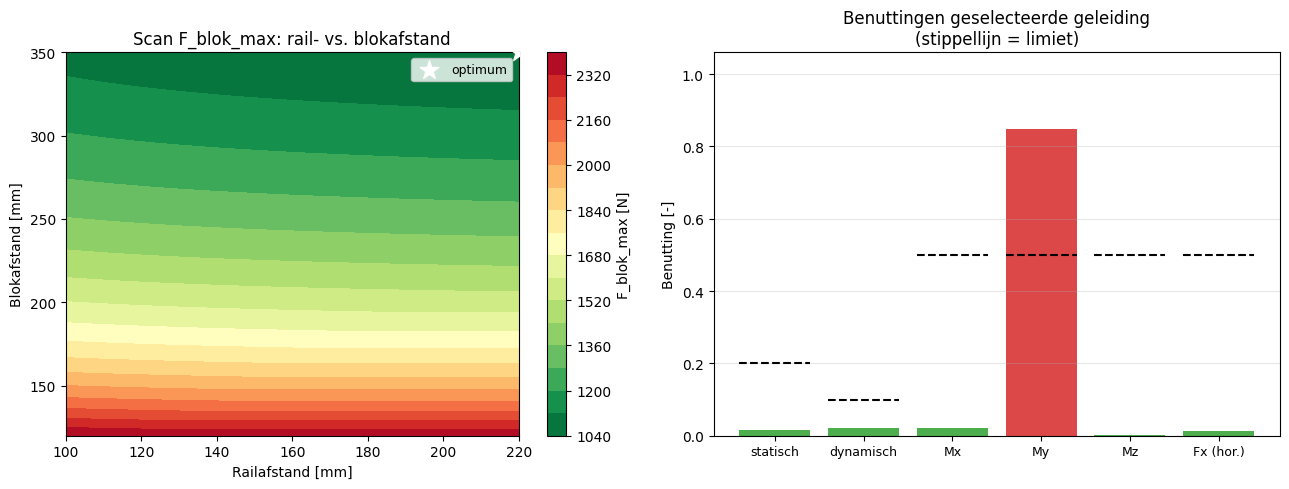

In [21]:
if len(scan_geometrie) > 0:
    toon_dataframe("top scan geometrie", scan_geometrie.head(15))
    plot_scan_geleidingen(scan_geometrie, beste_geometrie)

EXPORT

In [22]:

resultaten_geleidingen = {
    "configuratie":       asdict(cfg),
    "beste_geometrie":    beste_geometrie,
    "lastverdeling":      lastverdeling.copy(),
    "samenvatting_lasten": samenvatting_lasten.copy(),
    "eisen_geleiding":    eisen_geleiding.copy(),
    "controle_geleiding": controle_geleiding.copy(),
    "pass_fail_geleiding": pass_fail_geleiding.copy(),
    "overzicht_geleiding": overzicht_geleiding.copy(),
    "scan_geometrie":     scan_geometrie.copy(),
    "export_voor_volgende_modules": {
        "railafstand_m":              railafstand_m,
        "blokafstand_m":              blokafstand_m,
        "F_blok_max_N":               samenvatting_lasten["F_blok_max_N"],
        "F_blok_min_N":               samenvatting_lasten["F_blok_min_N"],
        "Fx_max_N":                   samenvatting_lasten["Fx_max_N"],
        "uplift_ergens":              samenvatting_lasten["uplift_ergens"],
        "aantal_uplift_lastgevallen": samenvatting_lasten["aantal_uplift_lastgevallen"],
        "Mx_max_Nm":                  samenvatting_lasten["Mx_max_Nm"],
        "My_max_Nm":                  samenvatting_lasten["My_max_Nm"],
        "Mz_max_Nm":                  samenvatting_lasten["Mz_max_Nm"],
        "levensduur_km":              controle_geleiding["levensduur_km"],
        "marge_levensduur":           controle_geleiding["marge_levensduur"],
        "benutting_statisch":         controle_geleiding["benutting_statisch"],
        "benutting_dynamisch":        controle_geleiding["benutting_dynamisch"],
    },
}

print("\n=== EXPORT VOOR VOLGENDE MODULES ===")
print(pd.Series(resultaten_geleidingen["export_voor_volgende_modules"]).to_string())


=== EXPORT VOOR VOLGENDE MODULES ===
railafstand_m                           0.22
blokafstand_m                           0.35
F_blok_max_N                     1044.035487
F_blok_min_N                     -398.390487
Fx_max_N                               105.3
uplift_ergens                           True
aantal_uplift_lastgevallen                 9
Mx_max_Nm                              17.04
My_max_Nm                             494.78
Mz_max_Nm                               1.39
levensduur_km                 2281494.263593
marge_levensduur                   392.81926
benutting_statisch                  0.014527
benutting_dynamisch                 0.021527
